# データサイエンス特論 第4回 演習課題
青山学院大学大学院 理工学研究科 理工学専攻 知能情報コース 修士1年 35626302 森下剛

## 二項分布

In [67]:
import numpy as np
from collections import Counter
from matplotlib import pyplot as plt

In [68]:
def bernoulli_trial(p):
    return 1 if np.random.random() < p else 0

In [69]:
def num_of_success(p, n):
    return sum(bernoulli_trial(p) for _ in range(n))

In [70]:
num_of_success(0.3, 10)

0

In [71]:
num_of_success(0.3, 10)

2

In [72]:
dist = [num_of_success(0.3, 10) for _ in range(10)]
print(dist)

[4, 5, 3, 2, 5, 3, 3, 5, 4, 2]


In [73]:
freq = Counter(dist)
print(freq)

Counter({5: 3, 3: 3, 4: 2, 2: 2})


In [74]:
Y = [freq[y]/10 for y in range(10)]
print(Y)

[0.0, 0.0, 0.2, 0.3, 0.2, 0.3, 0.0, 0.0, 0.0, 0.0]


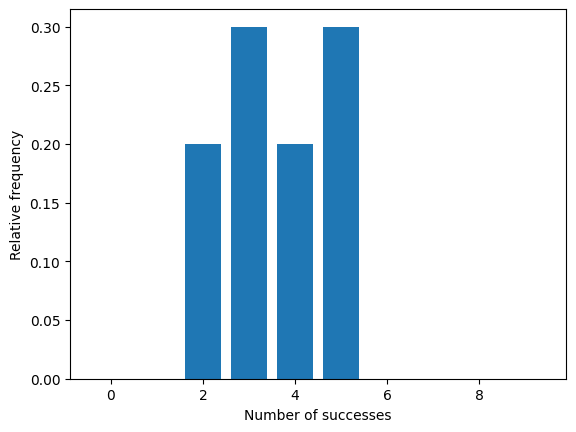

In [75]:
plt.bar([x for x in range(10)], Y)
plt.xlabel('Number of successes')
plt.ylabel('Relative frequency')
plt.show()


## 演習問題1

In [76]:
def plot_binomial(p, n, m):
    dist = [num_of_success(p, n) for _ in range(m)]
    freq = Counter(dist)
    Y = [freq[y]/m for y in range(n + 1)]
    plt.bar([x for x in range(n + 1)], Y)
    plt.xlabel('Number of successes')
    plt.ylabel('Relative frequency')
    plt.show()

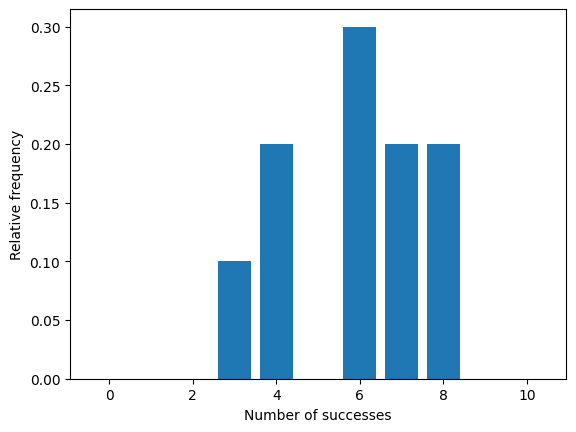

In [77]:
plot_binomial(0.5, 10, 10)

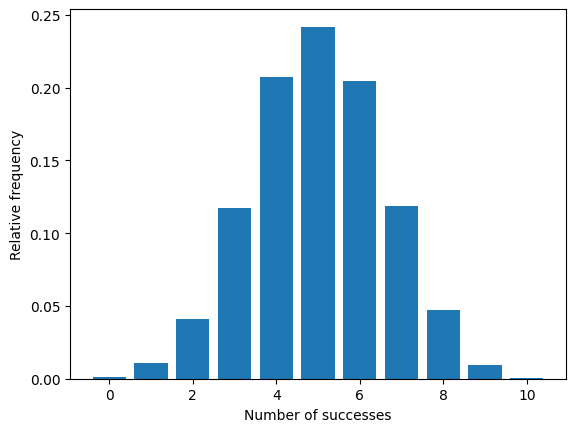

In [78]:
plot_binomial(0.5, 10, 10000)

## 正規分布の描画

In [79]:
from scipy.stats import norm

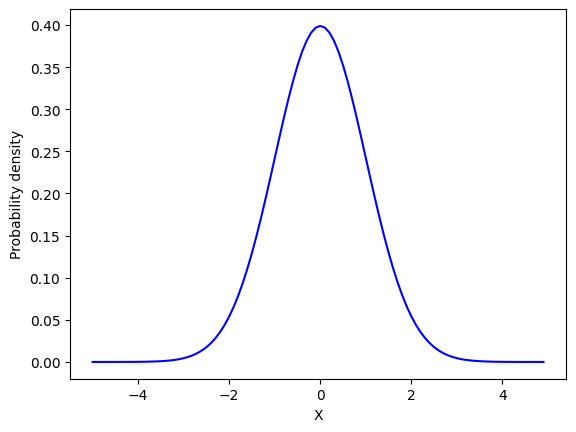

In [80]:
# 平均
mu = 0
# 標準偏差
sigma = 1
 
# 左端（平均-5*σ）
start = mu - sigma * 5
 
# 右端（平均+5*σ）
end = mu + sigma * 5
 
# X軸
X = np.arange(start, end, 0.1)
# 正規分布pdf生成
Y = norm.pdf(X, loc=mu, scale=sigma)
 
# プロットする
fig, ax = plt.subplots()
ax.plot(X, Y, color='blue')
ax.set_xlabel('X')
ax.set_ylabel('Probability density')
plt.show()

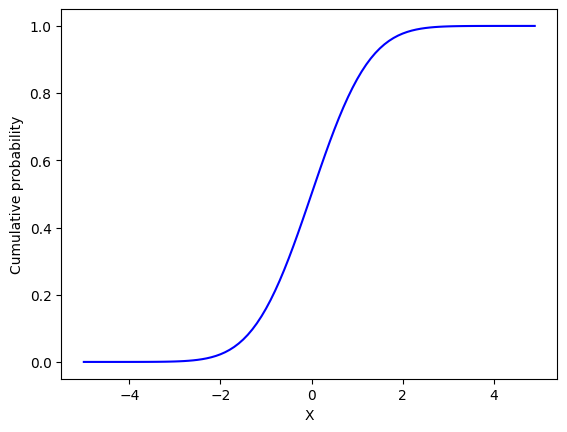

In [81]:
# 正規分布cdf生成
Y = norm.cdf(X, loc=mu, scale=sigma)
 
# プロットする
fig, ax = plt.subplots()
ax.plot(X, Y, color='blue')
ax.set_xlabel('X')
ax.set_ylabel('Cumulative probability')
plt.show()

## 演習問題2

In [82]:
prob = 1 - norm.cdf(2.0, loc=0, scale=1)
print(prob)

0.02275013194817921


## 演習問題3

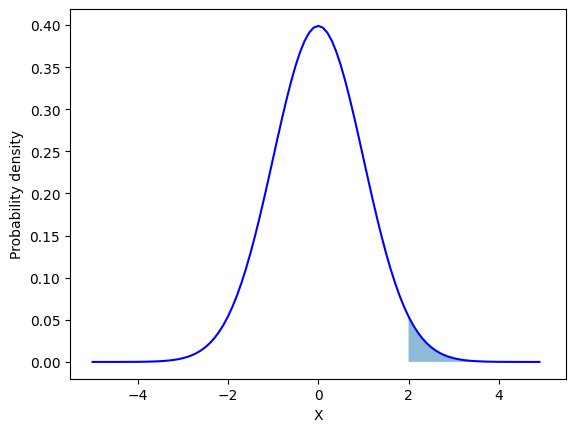

In [83]:
# 平均
mu = 0
# 標準偏差
sigma = 1
 
# 左端（平均-5*σ）
start = mu - sigma * 5
 
# 右端（平均+5*σ）
end = mu + sigma * 5
 
# X軸
X = np.arange(start, end, 0.1)
# 正規分布pdf生成
Y = norm.pdf(X, loc=mu, scale=sigma)
 
# プロットする
fig, ax = plt.subplots()
ax.plot(X, Y, color='blue')

X_fill = np.arange(2.0, mu + 5*sigma, 0.01)
Y_fill = norm.pdf(X_fill, loc=mu, scale=sigma)
ax.fill_between(X_fill, Y_fill, alpha=0.5)

ax.set_xlabel('X')
ax.set_ylabel('Probability density')
plt.show()

## 演習問題4

norm.ppf(): パーセント・ポイント関数

Percent Point Functionの頭文字

累積分布関数の値がaである場合のxの値（累積分布関数の逆関数）

レンダリングで指定の分布からサンプルを引くときに使用した記憶がある。

## 演習問題5


In [84]:
x = - norm.ppf(0.05, loc=0, scale=1)
print(x)

1.6448536269514729


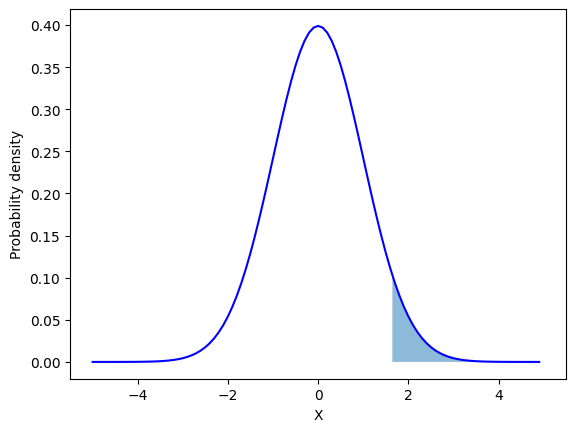

In [85]:
# 平均
mu = 0
# 標準偏差
sigma = 1
 
# 左端（平均-5*σ）
start = mu - sigma * 5
 
# 右端（平均+5*σ）
end = mu + sigma * 5
 
# X軸
X = np.arange(start, end, 0.1)
# 正規分布pdf生成
Y = norm.pdf(X, loc=mu, scale=sigma)
 
# プロットする
fig, ax = plt.subplots()
ax.plot(X, Y, color='blue')

X_fill = np.arange(x, mu + 5*sigma, 0.01)
Y_fill = norm.pdf(X_fill, loc=mu, scale=sigma)
ax.fill_between(X_fill, Y_fill, alpha=0.5)

ax.set_xlabel('X')
ax.set_ylabel('Probability density')
plt.show()

## 演習問題6

In [86]:
def norm_plot_fill_upper(mu, sigma, xrange, p):
    start = mu - xrange * sigma
    end = mu + xrange * sigma

    X = np.arange(start, end, 0.1)
    Y = norm.pdf(X, loc=mu, scale=sigma)
    
    fig, ax = plt.subplots()
    ax.plot(X, Y, color='blue')

    x_p = norm.ppf(1 - p, loc=mu, scale=sigma)

    X_fill = np.arange(x_p, mu + xrange * sigma, 0.01)
    Y_fill = norm.pdf(X_fill, loc=mu, scale=sigma)
    ax.fill_between(X_fill, Y_fill, alpha=0.5)

    ax.set_xlabel('X')
    ax.set_ylabel('Probability density')
    plt.show()

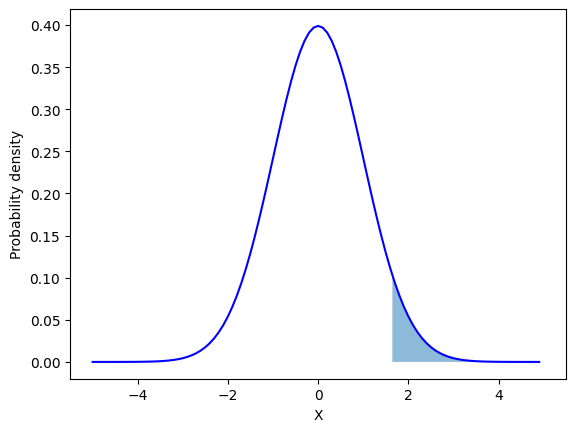

In [87]:
norm_plot_fill_upper(0, 1, 5, 0.05)

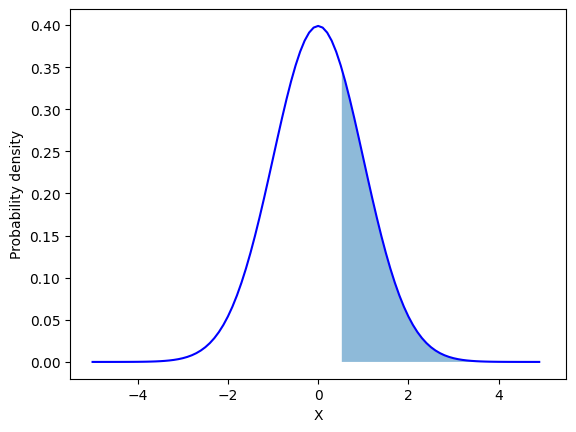

In [88]:
norm_plot_fill_upper(0, 1, 5, 0.3)

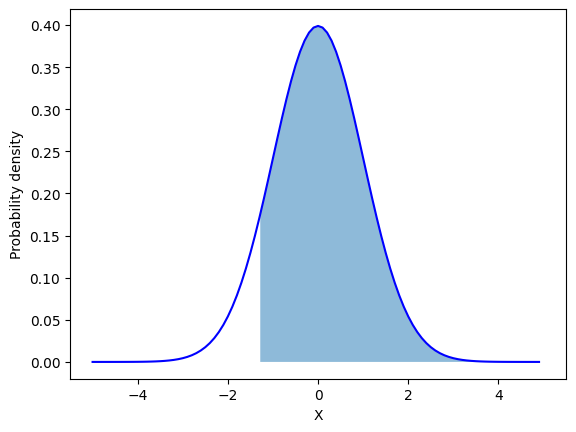

In [89]:
norm_plot_fill_upper(0, 1, 5, 0.9)